In [1]:
# ── Cell 1: Mount Drive & Imports ──────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive/MLP')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
import torchvision.transforms.functional as TF
import cv2

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, cohen_kappa_score
)
from tqdm.notebook import tqdm

from dataset import APTOSDataset

Mounted at /content/drive


In [2]:
# ── Cell 2: Paths ───────────────────────────────────────────────
# APTOS
APTOS_CSV       = "/content/drive/MyDrive/MLP/aptos_dataset/train.csv"
APTOS_IMAGE_DIR = "/content/drive/MyDrive/MLP/aptos_dataset"

# IDRiD — both splits
IDRID_TRAIN_CSV    = "/content/drive/MyDrive/MLP/idrid_dataset/ground_truth/training_labels.csv"
IDRID_TEST_CSV     = "/content/drive/MyDrive/MLP/idrid_dataset/ground_truth/testing_labels.csv"
IDRID_TRAIN_IMAGES = "/content/drive/MyDrive/MLP/idrid_dataset/original_images/training_images"
IDRID_TEST_IMAGES  = "/content/drive/MyDrive/MLP/idrid_dataset/original_images/testing_images"

# Model — loads the best saved checkpoint
BEST_MODEL_PATH = "/content/drive/MyDrive/MLP/dr_resnet50_best_batch32_ep10.pth"

RANDOM_SEED = 78
BATCH_SIZE  = 32


In [3]:
import os
os.makedirs("/content/drive/MyDrive/MLP/results", exist_ok=True)
print("✅ Results folder ready")

✅ Results folder ready


In [4]:
# ── Cell 3: Preprocessing Helpers ──────────────────────────────
class SquarePad:
    """Pads image to square before resizing, preserving aspect ratio."""
    def __call__(self, image):
        w, h = image.size
        max_wh = max(w, h)
        hp = (max_wh - w) // 2
        vp = (max_wh - h) // 2
        padding = [hp, vp, max_wh - w - hp, max_wh - h - vp]
        return TF.pad(image, padding, fill=0, padding_mode='constant')

transform_val = transforms.Compose([
    SquarePad(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

def make_thresholds(label):
    """Convert DR grade to ordinal threshold vector. e.g. 2 -> [1,1,0,0]"""
    return [1 if label >= i else 0 for i in range(1, 5)]

def decode_ordinal_predictions(logits):
    """Convert model logits to DR grade (0-4) via sigmoid thresholding."""
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).int()
    return preds.sum(dim=1)

In [5]:
# ── Cell 4: Load Model ──────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = resnet50(weights=ResNet50_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 4)

# ✅ Always load the best saved checkpoint, never rely on in-memory weights
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model = model.to(device)
model.eval()
print(f"✅ Best model loaded from {BEST_MODEL_PATH}")

Using device: cpu
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 138MB/s]


✅ Best model loaded from /content/drive/MyDrive/MLP/dr_resnet50_best_batch32_ep10.pth


In [6]:
# ── Cell 5: Build Full IDRiD Dataset (Train + Test combined) ───
# Load both splits
idrid_train_df = pd.read_csv(IDRID_TRAIN_CSV)
idrid_test_df  = pd.read_csv(IDRID_TEST_CSV)

# Clean column names
idrid_train_df.columns = idrid_train_df.columns.str.strip()
idrid_test_df.columns  = idrid_test_df.columns.str.strip()

# Keep relevant columns and rename to match APTOS format
idrid_train_df = idrid_train_df[['Image name', 'Retinopathy grade']].rename(
    columns={'Image name': 'id_code', 'Retinopathy grade': 'diagnosis'})
idrid_test_df  = idrid_test_df[['Image name', 'Retinopathy grade']].rename(
    columns={'Image name': 'id_code', 'Retinopathy grade': 'diagnosis'})

# Strip whitespace from id codes
idrid_train_df['id_code'] = idrid_train_df['id_code'].astype(str).str.strip()
idrid_test_df['id_code']  = idrid_test_df['id_code'].astype(str).str.strip()

# Add image directory column so we can build a combined dataset
# APTOSDataset uses a single img_dir, so we need separate loaders per split
# then concatenate predictions afterwards
idrid_train_df['thresholds'] = idrid_train_df['diagnosis'].apply(make_thresholds)
idrid_test_df['thresholds']  = idrid_test_df['diagnosis'].apply(make_thresholds)

# Build two datasets (different image folders) then evaluate separately
idrid_train_dataset = APTOSDataset(idrid_train_df, IDRID_TRAIN_IMAGES, transform_val)
idrid_test_dataset  = APTOSDataset(idrid_test_df,  IDRID_TEST_IMAGES,  transform_val)

idrid_train_loader = DataLoader(idrid_train_dataset, batch_size=BATCH_SIZE, shuffle=False)
idrid_test_loader  = DataLoader(idrid_test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"IDRiD train split: {len(idrid_train_dataset)} images")
print(f"IDRiD test split:  {len(idrid_test_dataset)} images")
print(f"IDRiD total:       {len(idrid_train_dataset) + len(idrid_test_dataset)} images")
print(f"\nIDRiD label distribution (full):")
print(pd.concat([idrid_train_df, idrid_test_df])['diagnosis'].value_counts().sort_index())

IDRiD train split: 413 images
IDRiD test split:  103 images
IDRiD total:       516 images

IDRiD label distribution (full):
diagnosis
0    168
1     25
2    168
3     93
4     62
Name: count, dtype: int64


In [7]:
# ── Cell 6: APTOS Validation Set Evaluation ────────────────────
# Rebuild APTOS val split using same seed as training
aptos_df = pd.read_csv(APTOS_CSV)
aptos_df = aptos_df[aptos_df['id_code'].apply(
    lambda x: os.path.exists(os.path.join(APTOS_IMAGE_DIR, x + ".png"))
)].reset_index(drop=True)
aptos_df['thresholds'] = aptos_df['diagnosis'].apply(make_thresholds)

_, val_df = train_test_split(
    aptos_df, test_size=0.2, stratify=aptos_df['diagnosis'], random_state=RANDOM_SEED
)

val_dataset = APTOSDataset(val_df, APTOS_IMAGE_DIR, transform_val)
val_loader  = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

aptos_preds, aptos_labels = [], []
with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="APTOS Validation"):
        images = images.to(device)
        logits = model(images)
        preds  = decode_ordinal_predictions(logits).cpu().numpy()
        true   = labels.numpy().sum(axis=1)
        aptos_preds.extend(preds)
        aptos_labels.extend(true)

aptos_preds  = np.array(aptos_preds)
aptos_labels = np.array(aptos_labels)
print("✅ APTOS validation complete")


APTOS Validation:   0%|          | 0/23 [00:00<?, ?it/s]

✅ APTOS validation complete


In [8]:
# ── Cell 7: Full IDRiD Evaluation ──────────────────────────────
idrid_preds, idrid_labels = [], []

# Evaluate train split
with torch.no_grad():
    for images, labels in tqdm(idrid_train_loader, desc="IDRiD Train Split"):
        images = images.to(device)
        logits = model(images)
        preds  = decode_ordinal_predictions(logits).cpu().numpy()
        true   = labels.numpy().sum(axis=1)
        idrid_preds.extend(preds)
        idrid_labels.extend(true)

# Evaluate test split
with torch.no_grad():
    for images, labels in tqdm(idrid_test_loader, desc="IDRiD Test Split"):
        images = images.to(device)
        logits = model(images)
        preds  = decode_ordinal_predictions(logits).cpu().numpy()
        true   = labels.numpy().sum(axis=1)
        idrid_preds.extend(preds)
        idrid_labels.extend(true)

idrid_preds  = np.array(idrid_preds)
idrid_labels = np.array(idrid_labels)
print(f"✅ Full IDRiD evaluation complete ({len(idrid_preds)} images)")

IDRiD Train Split:   0%|          | 0/13 [00:00<?, ?it/s]

IDRiD Test Split:   0%|          | 0/4 [00:00<?, ?it/s]

✅ Full IDRiD evaluation complete (516 images)


In [9]:
# ── Cell 8: Print All Metrics ───────────────────────────────────
def print_metrics(labels, preds, dataset_name):
    acc       = accuracy_score(labels, preds)
    precision = precision_score(labels, preds, average='macro', zero_division=0)
    recall    = recall_score(labels, preds, average='macro', zero_division=0)
    f1        = f1_score(labels, preds, average='macro', zero_division=0)
    qwk       = cohen_kappa_score(labels, preds, weights='quadratic')

    print(f"\n{'='*50}")
    print(f"  {dataset_name}")
    print(f"{'='*50}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall   : {recall:.4f}")
    print(f"  F1 Score : {f1:.4f}")
    print(f"  QWK      : {qwk:.4f}")
    print(f"{'='*50}")
    return qwk

aptos_qwk = print_metrics(aptos_labels, aptos_preds, "APTOS (In-Domain Validation)")
idrid_qwk = print_metrics(idrid_labels, idrid_preds, "IDRiD (Full Cross-Domain)")
print(f"\n  QWK Retention: {(idrid_qwk / aptos_qwk) * 100:.2f}%")


  APTOS (In-Domain Validation)
  Accuracy : 0.7858
  Precision: 0.6629
  Recall   : 0.6426
  F1 Score : 0.6110
  QWK      : 0.8967

  IDRiD (Full Cross-Domain)
  Accuracy : 0.4457
  Precision: 0.5416
  Recall   : 0.4306
  F1 Score : 0.3964
  QWK      : 0.7155

  QWK Retention: 79.79%


In [10]:
# ── Cell 9: Stage-wise Comparison Table ────────────────────────
def get_stage_metrics(labels, preds):
    cm = confusion_matrix(labels, preds, labels=[0, 1, 2, 3, 4])
    stats = []
    for stage in range(5):
        tp             = cm[stage, stage]
        actual_total   = cm[stage, :].sum()
        pred_total     = cm[:, stage].sum()
        sens = tp / actual_total if actual_total > 0 else 0
        prec = tp / pred_total   if pred_total   > 0 else 0
        stats.append({"Sensitivity": sens, "Precision": prec})
    return stats

aptos_m = get_stage_metrics(aptos_labels, aptos_preds)
idrid_m  = get_stage_metrics(idrid_labels, idrid_preds)
stages   = ['0 (Normal)', '1 (Mild)', '2 (Moderate)', '3 (Severe)', '4 (Prolif)']

rows = []
for i in range(5):
    rows.append({
        'DR Stage':       stages[i],
        'APTOS Sens':     aptos_m[i]['Sensitivity'],
        'APTOS Prec':     aptos_m[i]['Precision'],
        'IDRiD Sens':     idrid_m[i]['Sensitivity'],
        'IDRiD Prec':     idrid_m[i]['Precision'],
        'Sens Drop (%)': (aptos_m[i]['Sensitivity'] - idrid_m[i]['Sensitivity']) * 100
    })

master_df = pd.DataFrame(rows)
print("\n" + "="*90)
print(master_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print(f"\nOVERALL QWK | APTOS: {aptos_qwk:.4f} | IDRiD: {idrid_qwk:.4f} | "
      f"Retention: {(idrid_qwk/aptos_qwk)*100:.2f}%")
print("="*90)


    DR Stage  APTOS Sens  APTOS Prec  IDRiD Sens  IDRiD Prec  Sens Drop (%)
  0 (Normal)      0.9917      0.9755      0.4583      0.7857        53.3356
    1 (Mild)      0.7297      0.6353      0.5200      0.0855        20.9730
2 (Moderate)      0.6300      0.7590      0.4702      0.5852        15.9762
  3 (Severe)      0.6410      0.2604      0.5591      0.4333         8.1886
  4 (Prolif)      0.2203      0.6842      0.1452      0.8182         7.5178

OVERALL QWK | APTOS: 0.8967 | IDRiD: 0.7155 | Retention: 79.79%


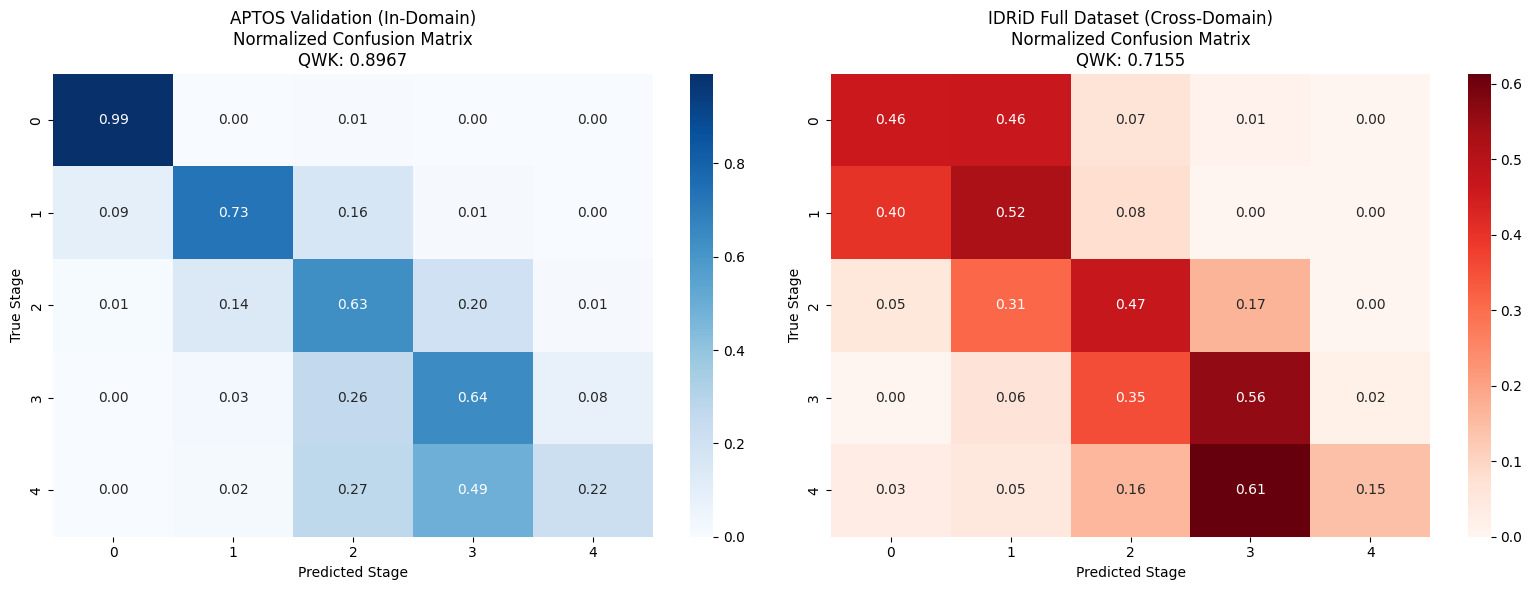

✅ Confusion matrix saved


In [11]:
# ── Cell 10: Dual Confusion Matrix ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_aptos      = confusion_matrix(aptos_labels, aptos_preds)
cm_aptos_norm = cm_aptos.astype('float') / cm_aptos.sum(axis=1)[:, np.newaxis]

cm_idrid      = confusion_matrix(idrid_labels, idrid_preds)
cm_idrid_norm = cm_idrid.astype('float') / cm_idrid.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm_aptos_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[0],
            xticklabels=[0,1,2,3,4], yticklabels=[0,1,2,3,4])
axes[0].set_title(f'APTOS Validation (In-Domain)\nNormalized Confusion Matrix\nQWK: {aptos_qwk:.4f}')
axes[0].set_xlabel('Predicted Stage')
axes[0].set_ylabel('True Stage')

sns.heatmap(cm_idrid_norm, annot=True, fmt='.2f', cmap='Reds', ax=axes[1],
            xticklabels=[0,1,2,3,4], yticklabels=[0,1,2,3,4])
axes[1].set_title(f'IDRiD Full Dataset (Cross-Domain)\nNormalized Confusion Matrix\nQWK: {idrid_qwk:.4f}')
axes[1].set_xlabel('Predicted Stage')
axes[1].set_ylabel('True Stage')

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/MLP/results/confusion_matrices_full_idrid.png", dpi=150)
plt.show()
print("✅ Confusion matrix saved")


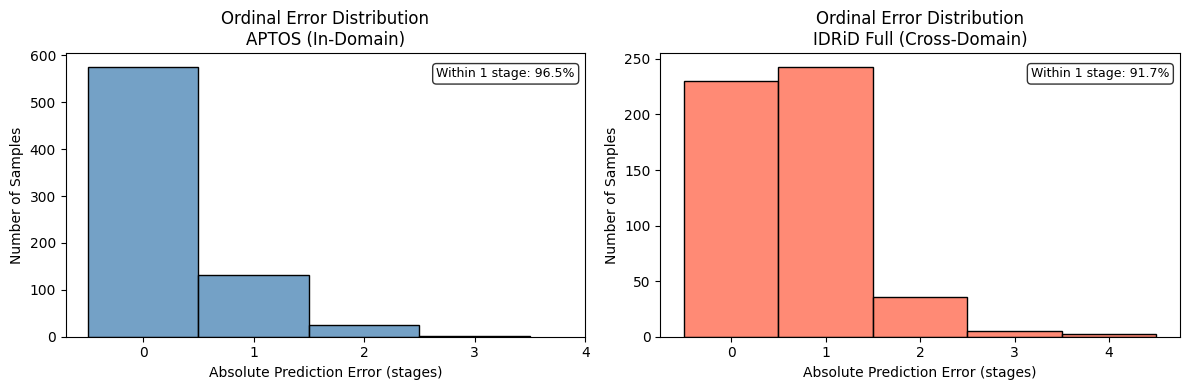

✅ Ordinal error plot saved


In [12]:
# ── Cell 11: Ordinal Error Distribution ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, labels, preds, title, colour in [
    (axes[0], aptos_labels, aptos_preds, "APTOS (In-Domain)", "steelblue"),
    (axes[1], idrid_labels, idrid_preds, "IDRiD Full (Cross-Domain)", "tomato")
]:
    errors = np.abs(labels - preds)
    sns.histplot(errors, bins=np.arange(0, 6) - 0.5, discrete=True, ax=ax, color=colour)
    ax.set_title(f'Ordinal Error Distribution\n{title}')
    ax.set_xlabel('Absolute Prediction Error (stages)')
    ax.set_ylabel('Number of Samples')
    ax.set_xticks(range(5))
    within_1 = (errors <= 1).mean() * 100
    ax.text(0.98, 0.95, f'Within 1 stage: {within_1:.1f}%',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/MLP/results/ordinal_error_full_idrid.png", dpi=150)
plt.show()
print("✅ Ordinal error plot saved")



Generating Grad-CAM for IDRiD train split...
✅ Grad-CAM saved → /content/drive/MyDrive/MLP/results/gradcam_idrid_train.png


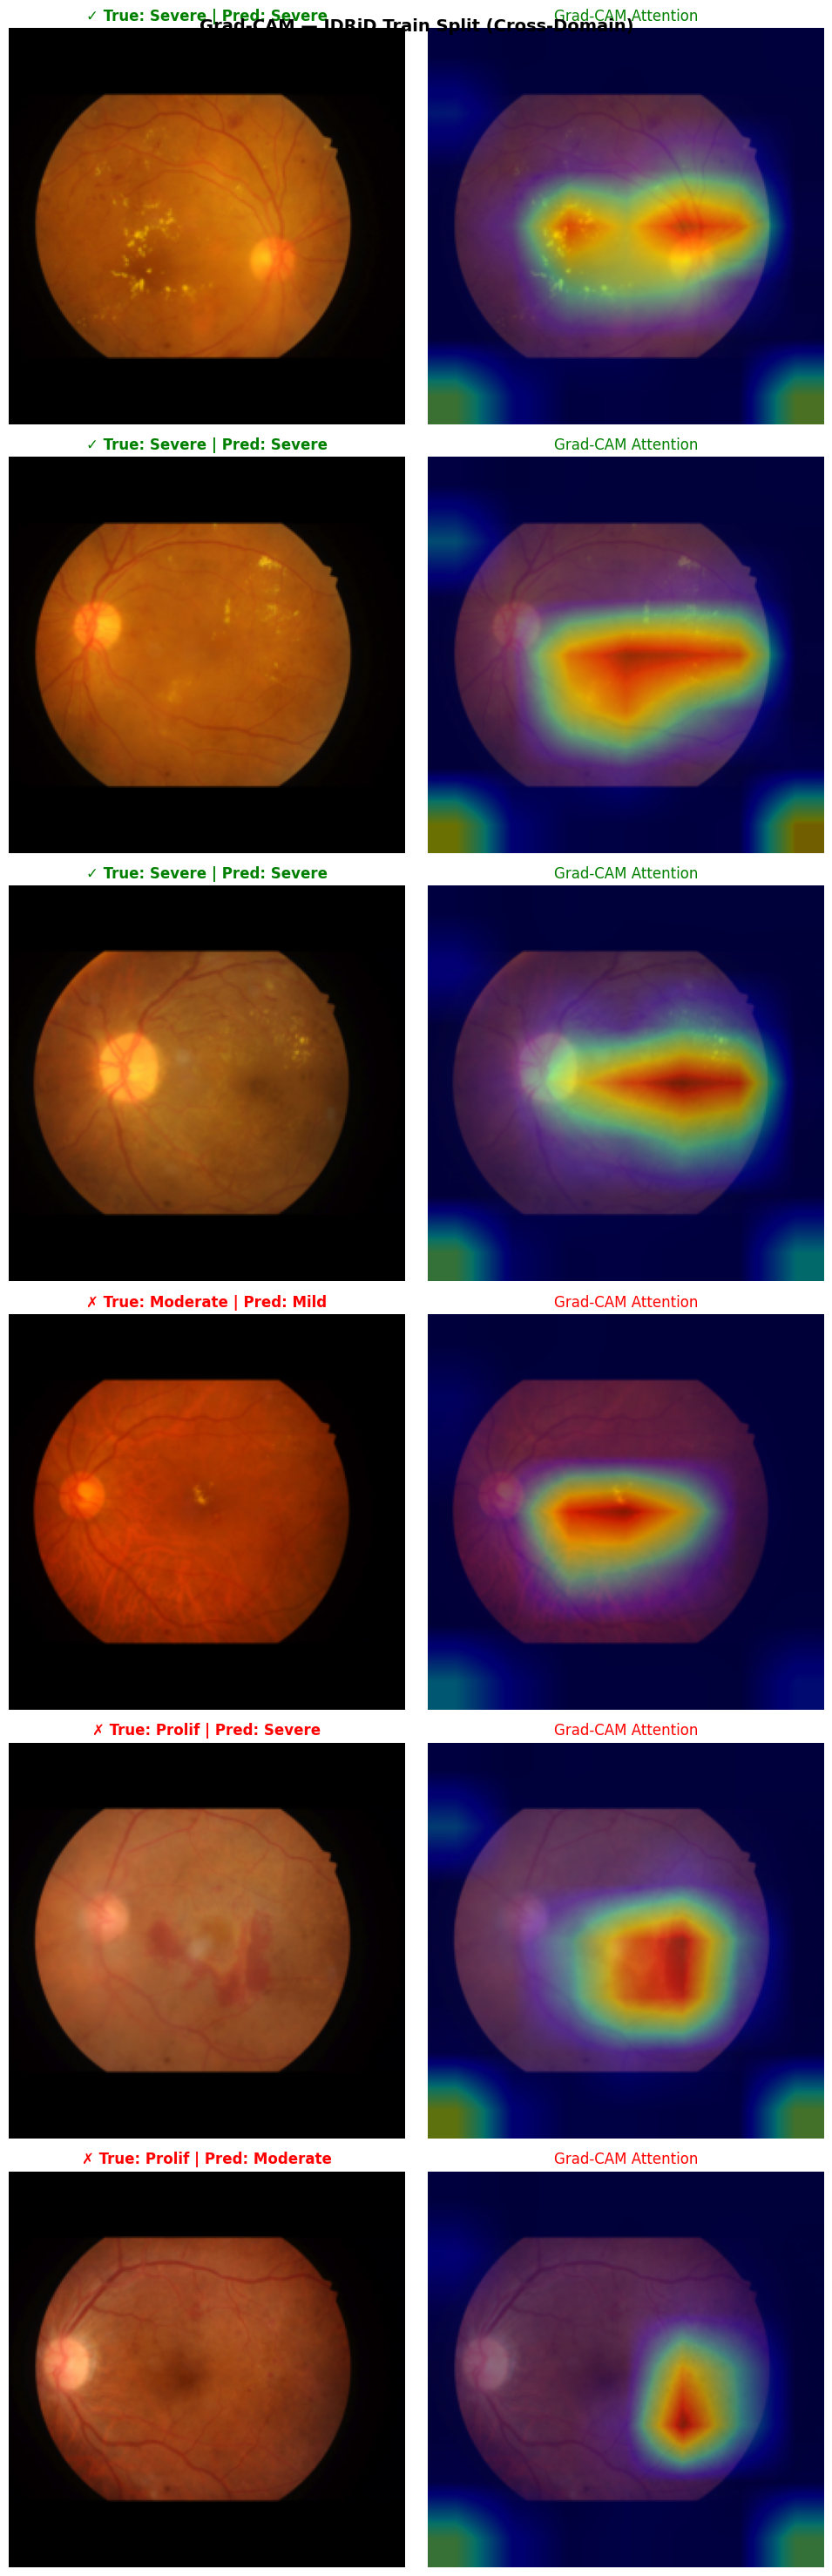

Generating Grad-CAM for IDRiD test split...
✅ Grad-CAM saved → /content/drive/MyDrive/MLP/results/gradcam_idrid_test.png


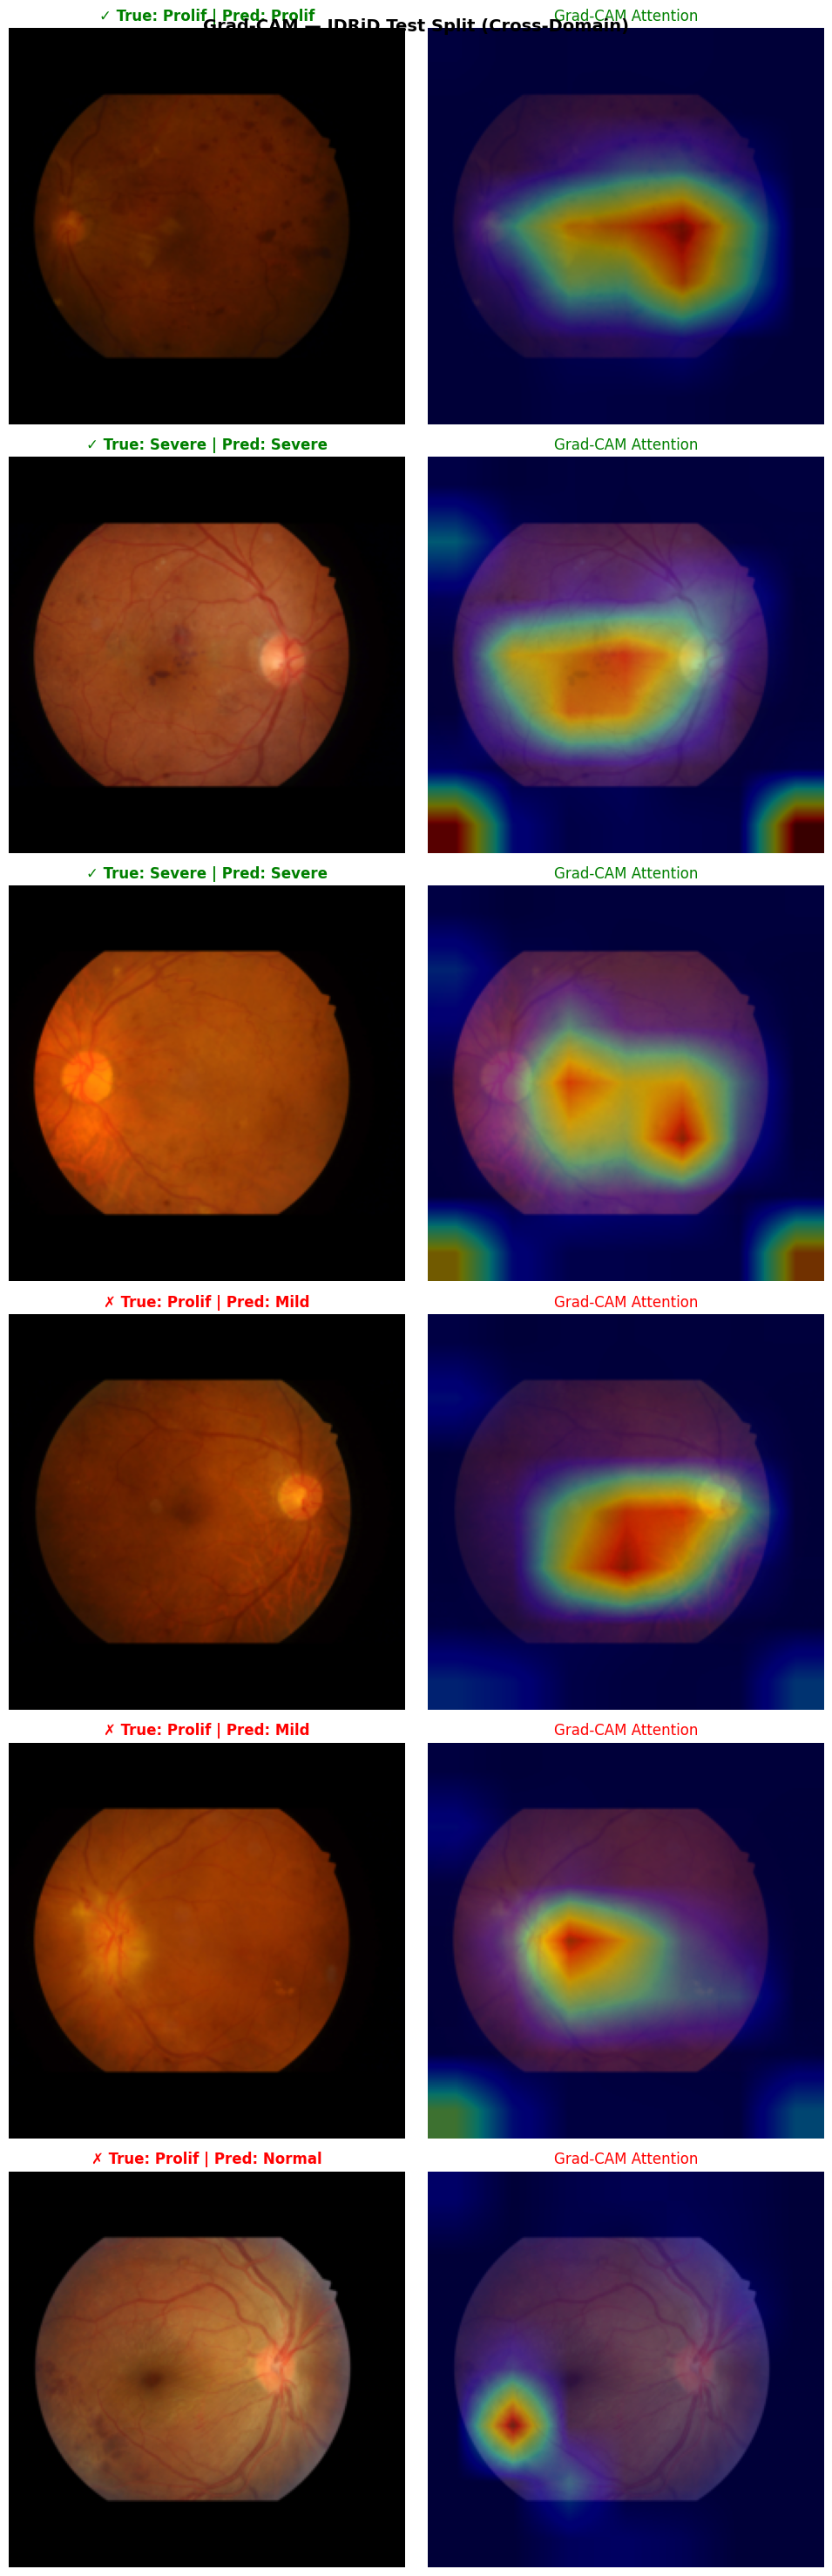

In [13]:
# ── Cell 12: Grad-CAM ───────────────────────────────────────────
def generate_gradcam(model, input_tensor, target_layer):
    """Generate Grad-CAM heatmap for a single image tensor."""
    model.eval()
    gradients  = []
    activations = []

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    def forward_hook(module, input, output):
        activations.append(output)

    handle_b = target_layer.register_full_backward_hook(backward_hook)
    handle_f = target_layer.register_forward_hook(forward_hook)

    logits = model(input_tensor)
    score  = logits[:, logits.argmax(dim=1)].sum()
    model.zero_grad()
    score.backward()

    grads   = gradients[0].cpu().data.numpy()
    f_maps  = activations[0].cpu().data.numpy()
    weights = np.mean(grads, axis=(2, 3))[0]

    cam = np.zeros(f_maps.shape[2:], dtype=np.float32)
    for i, w in enumerate(weights):
        cam += w * f_maps[0, i, :, :]

    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (224, 224))
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    handle_b.remove()
    handle_f.remove()

    return cam, logits.argmax(dim=1).item()

def plot_gradcam_grid(model, dataset, device, n_samples=6, title="Grad-CAM", save_path=None):
    """
    Plot Grad-CAM for n_samples images, showing correct (green) and
    incorrect (red) predictions side by side.
    """
    # Collect indices for correct and wrong predictions separately
    correct_indices = []
    wrong_indices   = []

    model.eval()
    with torch.no_grad():
        for idx in range(len(dataset)):
            img_tensor, label_vec = dataset[idx]
            true = int(label_vec.sum().item())
            logits = model(img_tensor.unsqueeze(0).to(device))
            pred   = decode_ordinal_predictions(logits).item()
            if pred == true and len(correct_indices) < n_samples // 2:
                correct_indices.append((idx, true, pred))
            elif pred != true and len(wrong_indices) < n_samples // 2:
                wrong_indices.append((idx, true, pred))
            if len(correct_indices) + len(wrong_indices) >= n_samples:
                break

    sample_info = correct_indices + wrong_indices
    n = len(sample_info)

    fig, axes = plt.subplots(n, 2, figsize=(10, 5 * n))
    if n == 1:
        axes = axes[np.newaxis, :]

    stage_names = ['Normal', 'Mild', 'Moderate', 'Severe', 'Prolif']

    for row, (idx, true, pred) in enumerate(sample_info):
        img_tensor, _ = dataset[idx]
        input_batch   = img_tensor.unsqueeze(0).to(device)

        heatmap, _ = generate_gradcam(model, input_batch, model.layer4)

        img = img_tensor.cpu().numpy().transpose(1, 2, 0)
        img = (img * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
        img = np.clip(img, 0, 1)

        correct = (true == pred)
        colour  = 'green' if correct else 'red'
        status  = '✓' if correct else '✗'

        axes[row, 0].imshow(img)
        axes[row, 0].set_title(
            f"{status} True: {stage_names[true]} | Pred: {stage_names[pred]}",
            color=colour, fontweight='bold'
        )
        axes[row, 0].axis('off')

        axes[row, 1].imshow(img)
        axes[row, 1].imshow(heatmap, cmap='jet', alpha=0.45)
        axes[row, 1].set_title("Grad-CAM Attention", color=colour)
        axes[row, 1].axis('off')

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✅ Grad-CAM saved → {save_path}")

    plt.show()

os.makedirs("/content/drive/MyDrive/MLP/results", exist_ok=True)

# Grad-CAM on IDRiD train split samples
print("Generating Grad-CAM for IDRiD train split...")
plot_gradcam_grid(
    model, idrid_train_dataset, device,
    n_samples=6,
    title="Grad-CAM — IDRiD Train Split (Cross-Domain)",
    save_path="/content/drive/MyDrive/MLP/results/gradcam_idrid_train.png"
)

# Grad-CAM on IDRiD test split samples
print("Generating Grad-CAM for IDRiD test split...")
plot_gradcam_grid(
    model, idrid_test_dataset, device,
    n_samples=6,
    title="Grad-CAM — IDRiD Test Split (Cross-Domain)",
    save_path="/content/drive/MyDrive/MLP/results/gradcam_idrid_test.png"
)


In [14]:
# ── Cell 13: Final Summary ──────────────────────────────────────
print("\n" + "="*60)
print("  EVALUATION COMPLETE")
print("="*60)
print(f"  APTOS val set     : {len(aptos_labels)} images")
print(f"  IDRiD full dataset: {len(idrid_labels)} images "
      f"({len(idrid_train_dataset)} train + {len(idrid_test_dataset)} test)")
print(f"\n  APTOS QWK : {aptos_qwk:.4f}")
print(f"  IDRiD QWK : {idrid_qwk:.4f}")
print(f"  Retention : {(idrid_qwk/aptos_qwk)*100:.2f}%")
print("="*60)
print("\nAll results saved to /content/drive/MyDrive/MLP/results/")




  EVALUATION COMPLETE
  APTOS val set     : 733 images
  IDRiD full dataset: 516 images (413 train + 103 test)

  APTOS QWK : 0.8967
  IDRiD QWK : 0.7155
  Retention : 79.79%

All results saved to /content/drive/MyDrive/MLP/results/


In [15]:
import os
import datetime

path = "/content/drive/MyDrive/MLP/dr_resnet50_best_model.pth"

modified = os.path.getmtime(path)
print("Last saved:", datetime.datetime.fromtimestamp(modified))
print(f"File size: {os.path.getsize(path) / (1024*1024):.1f} MB")

Last saved: 2026-03-18 20:11:13
File size: 90.0 MB


In [16]:
import os

mlp_dir = "/content/drive/MyDrive/MLP"

for f in os.listdir(mlp_dir):
    if f.endswith('.pth'):
        path = os.path.join(mlp_dir, f)
        size = os.path.getsize(path) / (1024*1024)
        modified = datetime.datetime.fromtimestamp(os.path.getmtime(path))
        print(f"{f:50s} | {size:.1f} MB | {modified}")

dr_resnet50_best_model.pth                         | 90.0 MB | 2026-03-18 20:11:13
dr_resnet50_checkpoint.pth                         | 269.6 MB | 2026-03-18 21:17:12
dr_resnet50_best_batch32_ep10.pth                  | 90.0 MB | 2026-03-23 00:35:46
dr_resnet50_checkpoint_batch32_ep10.pth            | 269.6 MB | 2026-03-23 04:24:46


In [17]:
checkpoint = torch.load("/content/drive/MyDrive/MLP/dr_resnet50_checkpoint.pth", map_location='cpu')
print(f"Epoch: {checkpoint['epoch'] + 1}")
print(f"Val loss: {checkpoint['val_loss']:.4f}")
print(f"Train loss: {checkpoint['train_loss']:.4f}")

Epoch: 5
Val loss: 0.1245
Train loss: 0.1006
